# He II 1640Å Recombination Emissivity
**Cloudy (full RT)** vs **Case B (PyNeb, Storey & Hummer 1995)** 비교

- He II는 수소유사(H-like) 이온 (Z=2) → 1640Å = n=3→2 (Balmer-α 유사)
- **Case B**: He II Lyα (303.78Å, n=2→1)는 광학적으로 두꺼워 재흡수됨
- T_e, n_e, n(He²⁺) 모두 반경에 따라 변하므로 **zone별로 따로 계산**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyCloudy as pc
import pyneb as pn
from astropy import constants as const
import warnings
warnings.filterwarnings('ignore')

kpc = const.kpc.cgs.value

# PyNeb He II RecAtom — Storey & Hummer (1995), T range: 500–30000 K
HE2 = pn.RecAtom('He', 2)
print(f'PyNeb version: {pn.__version__}')
print(f'He II sources: {HE2.sources}')

PyNeb version: 1.1.30
He II sources: ['Storey and Hummer 1995', 'Ref.  of NIST 2014 (try this: http://physics.nist.gov/cgi-bin/ASBib1/get_ASBib_ref.cgi?db=el&db_id=&comment_code=&element=He&spectr_charge=2&', 'Ref. 3620c107 of NIST 2014 (try this: http://physics.nist.gov/cgi-bin/ASBib1/get_ASBib_ref.cgi?db=el&db_id=3620c107&comment_code=&element=He&spectr_charge=2&']


## 파라미터 설정

In [2]:
# ── 여기서 모델 파라미터를 바꿔가며 비교 ──
Lumin                 = 44.0   # log L [erg/s]
metals                = 1.0    # metallicity (solar)
Column_density_order  = 22.0   # log N_H [cm⁻²]

frac_He = 0.10   # He/H 비율 (by number)
WAVE    = 1640   # Å — 비교할 He II 방출선

## Cloudy 모델 불러오기

In [3]:
import sys, os
sys.path.insert(0, os.path.expanduser('~/RT_JIN'))
from RT_v1 import resolve_column_density_path

path = resolve_column_density_path(Lumin, metals, Column_density_order, 'CIV/CLOUDY_QSO')
print('Cloudy 경로:', path)

Mod = pc.CloudyModel(path)

Cloudy 경로: /home/jinlim/CIV_RT_scat_data/CLOUDY_setup/Lum_44.0_2/metal_1.0/N_H_1.0_22.0/CIV/CLOUDY_QSO


In [4]:
# ── .ele 파일에서 이온 분율 읽기 ──────────────────────────────────────────────
def read_ele(path, element, ion_stage):
    """ion_stage번째 이온 분율. col 0=depth, col 1=neutral, col 2=1st ion, …"""
    data = np.genfromtxt(f'{path}.ele_{element}')
    return data[:, ion_stage]

# 반경별 물리량
nH         = Mod.nH                          # cm⁻³
n_He       = nH * frac_He                    # cm⁻³
Te         = Mod.te                          # K
ne         = Mod.ne                          # cm⁻³
dr         = Mod.dr                          # cm (각 zone 두께)
radius_kpc = Mod.radius / kpc               # kpc
radius_cm  = Mod.radius                     # cm

HeII_frac  = read_ele(path, 'He', 2)        # He²⁺ 분율
HeIII_frac = read_ele(path, 'He', 3)        # He³⁺ 분율
nden_HeII  = HeII_frac * n_He               # He²⁺ 수밀도 [cm⁻³]

# Cloudy 직접 계산 emissivity
emis_cloudy = Mod.get_emis('HE_2_164043A')  # erg/s/cm³

print(f'Zones: {len(Te)}')
print(f'T_e  range: {Te.min():.1f} – {Te.max():.1f} K')
print(f'n_e  range: {ne.min():.2e} – {ne.max():.2e} cm⁻³')
print(f'n(He²⁺) range: {nden_HeII.min():.2e} – {nden_HeII.max():.2e} cm⁻³')

Zones: 479
T_e  range: 97.4 – 125880.0 K
n_e  range: 6.55e-05 – 9.07e-02 cm⁻³
n(He²⁺) range: 1.98e-07 – 5.05e-03 cm⁻³


## Case B emissivity 계산 (PyNeb)

$$\varepsilon(r) = j_\lambda(T_e(r),\, n_e(r)) \times n_e(r) \times n(\text{He}^{2+})(r)$$

- `product=False` : 각 zone을 pairwise 계산 (True이면 T×ne 2D grid)
- T > 30,000 K zone : PyNeb 테이블 범위 초과 → NaN

In [5]:
from RT_v1 import * 
T_MAX_PYNEB = 30000.0  # K

# zone별 j_λ(T_e, n_e)  [erg·s⁻¹·cm³]
j_pyneb = HE2.getEmissivity(Te, ne, wave=WAVE, product=False)

h_erg = h.to(u.erg*u.s).value

lam   = 1640.42e-8              # cm  (He II 1640)
nu_1640   = c_cms / lam            

hnu_1640 = h_erg * nu_1640 # erg
# emissivity [erg/s/cm³]
nden_HeIII = nden_HeII * (HeIII_frac / HeII_frac )
emis_caseB = j_pyneb * ne * nden_HeIII

# T 범위 초과 zone 확인
mask_outT  = Te > T_MAX_PYNEB
mask_valid = ~mask_outT & np.isfinite(emis_caseB)

print(f'T > {T_MAX_PYNEB:.0f} K zone: {mask_outT.sum()} / {len(Te)}')
print(f'T_max in out-of-range zones: {Te[mask_outT].max():.0f} K  (주로 He³⁺ 우세 구간)')

# 비율
ratio = np.where(emis_cloudy > 0, emis_caseB / emis_cloudy, np.nan)

T > 30000 K zone: 72 / 479
T_max in out-of-range zones: 125880 K  (주로 He³⁺ 우세 구간)


## 결과 요약

In [6]:
int_cloudy = np.trapz(emis_cloudy,            radius_cm)
int_caseB  = np.trapz(np.nan_to_num(emis_caseB), radius_cm)

print(f'He II {WAVE}Å  |  Lum={Lumin}, Z={metals}, logNH={Column_density_order}')
print(f'  ∫ emis dr  Cloudy : {int_cloudy:.3e} erg/s/cm²')
print(f'  ∫ emis dr  Case B : {int_caseB:.3e} erg/s/cm²')
print(f'  Ratio (Case B / Cloudy) : {int_caseB/int_cloudy:.3f}')
print()
print(f'  j_1640 at T=10⁴K, ne=100: {HE2.getEmissivity(1e4, 100, wave=WAVE):.3e} erg·s⁻¹·cm³')

He II 1640Å  |  Lum=44.0, Z=1.0, logNH=22.0
  ∫ emis dr  Cloudy : 7.268e-05 erg/s/cm²
  ∫ emis dr  Case B : 9.407e-05 erg/s/cm²
  Ratio (Case B / Cloudy) : 1.294

  j_1640 at T=10⁴K, ne=100: 9.815e-24 erg·s⁻¹·cm³


## 비교 플롯

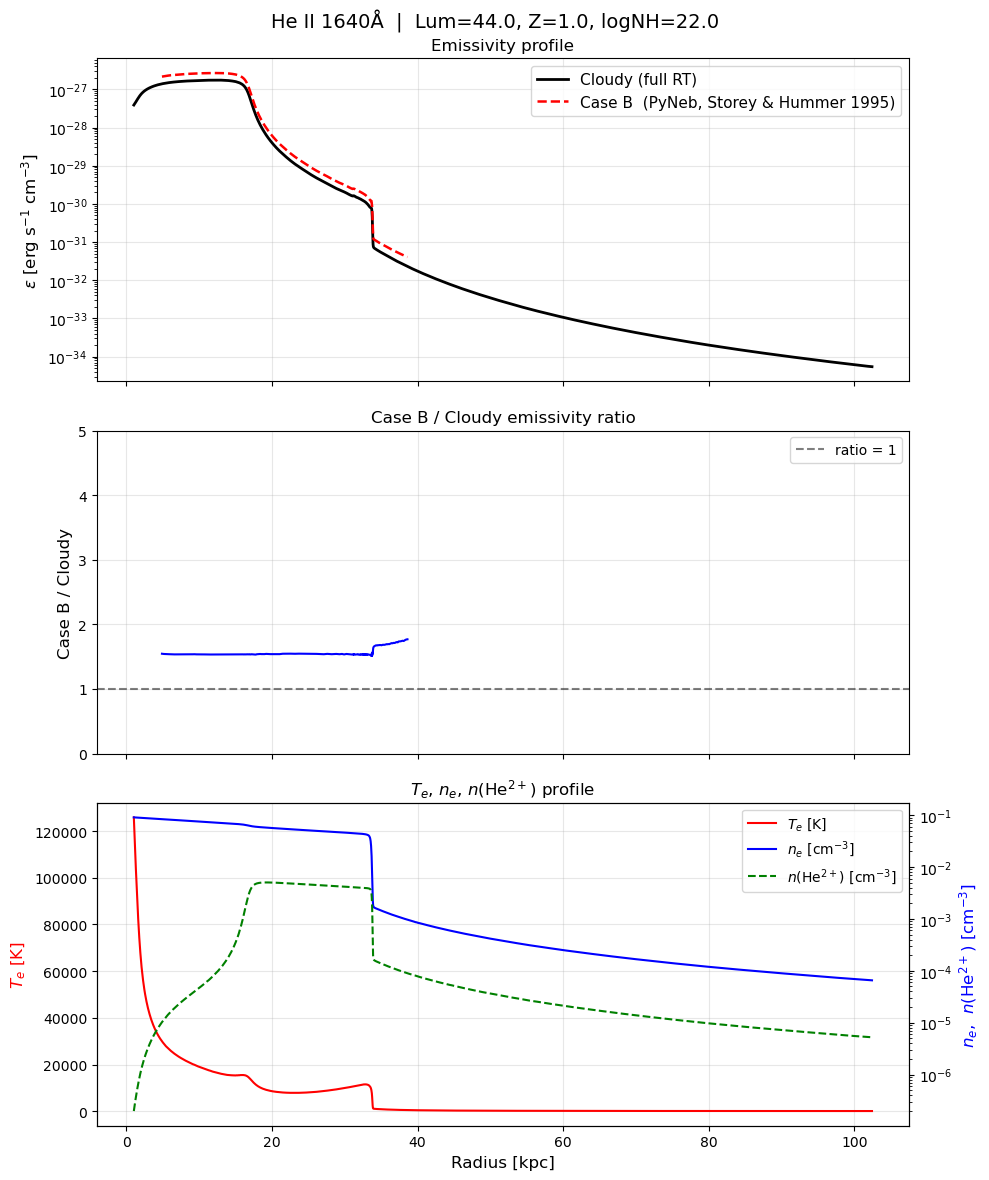

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
fig.suptitle(f'He II {WAVE}Å  |  Lum={Lumin}, Z={metals}, logNH={Column_density_order}',
             fontsize=14)

# (1) Emissivity 비교
ax = axes[0]
ax.plot(radius_kpc, emis_cloudy, 'k-',  lw=2,   label='Cloudy (full RT)')
ax.plot(radius_kpc, emis_caseB,  'r--', lw=1.8, label='Case B  (PyNeb, Storey & Hummer 1995)')
ax.set_yscale('log')
ax.set_ylabel(r'$\varepsilon$ [erg s$^{-1}$ cm$^{-3}$]', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_title('Emissivity profile')

# (2) Ratio
ax = axes[1]
ax.plot(radius_kpc, ratio, 'b-', lw=1.5)
ax.axhline(1.0, color='k', ls='--', alpha=0.5, label='ratio = 1')
ax.set_ylabel('Case B / Cloudy', fontsize=12)
ax.set_ylim(0, 5)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_title('Case B / Cloudy emissivity ratio')

# (3) Te, ne, n(He²⁺) profile
ax = axes[2]
ax_ne = ax.twinx()
l1, = ax.plot(radius_kpc, Te,        'r-',  lw=1.5, label=r'$T_e$ [K]')
l2, = ax_ne.plot(radius_kpc, ne,     'b-',  lw=1.5, label=r'$n_e$ [cm$^{-3}$]')
l3, = ax_ne.plot(radius_kpc, nden_HeII, 'g--', lw=1.5, label=r'$n(\mathrm{He}^{2+})$ [cm$^{-3}$]')
ax.set_xlabel('Radius [kpc]', fontsize=12)
ax.set_ylabel(r'$T_e$ [K]', fontsize=12, color='r')
ax_ne.set_ylabel(r'$n_e$,  $n(\mathrm{He}^{2+})$ [cm$^{-3}$]', fontsize=12, color='b')
ax_ne.set_yscale('log')
ax.legend(handles=[l1, l2, l3], fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_title(r'$T_e$, $n_e$, $n(\mathrm{He}^{2+})$ profile')

plt.tight_layout()
plt.savefig(f'HeII_compare_L{Lumin}_Z{metals}_N{Column_density_order}.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 이온화 분율 프로파일

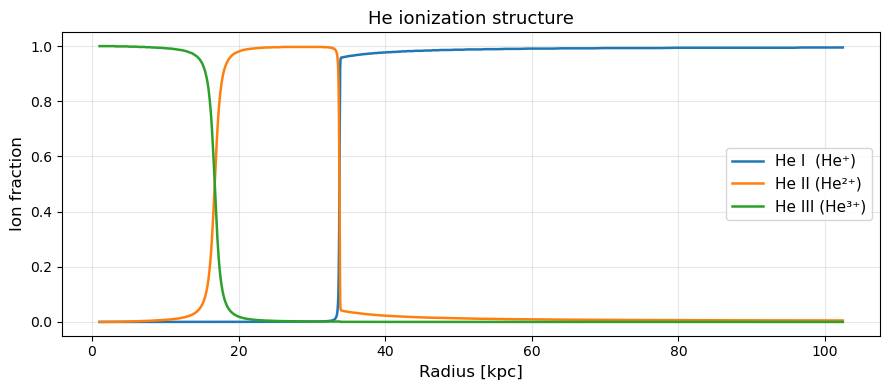

In [8]:
HeI_frac  = read_ele(path, 'He', 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(radius_kpc, HeI_frac,   label='He I  (He⁺)',  lw=1.8)
ax.plot(radius_kpc, HeII_frac,  label='He II (He²⁺)', lw=1.8)
ax.plot(radius_kpc, HeIII_frac, label='He III (He³⁺)', lw=1.8)
ax.set_xlabel('Radius [kpc]', fontsize=12)
ax.set_ylabel('Ion fraction', fontsize=12)
ax.legend(fontsize=11)
ax.set_title('He ionization structure', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## PyNeb j_λ(T) 테이블 확인

In [9]:
T_grid = np.array([5000, 8000, 10000, 12000, 15000, 20000, 25000, 30000])
ne_ref  = 100.0

j1640 = HE2.getEmissivity(T_grid, ne_ref, wave=1640)
j4686 = HE2.getEmissivity(T_grid, ne_ref, wave=4686)

# print(f'  {'T [K]':>10}  {'j_1640 [erg\s⁻¹\cm³]':>22}  {'j_4686':>22}')
# print('  ' + '-'*58)
# for T, j1, j4 in zip(T_grid, j1640, j4686):
    # print(f'  {T:>10.0f}  {j1:>22.4e}  {j4:>22.4e}')

## 여러 모델 파라미터 비교 (선택)

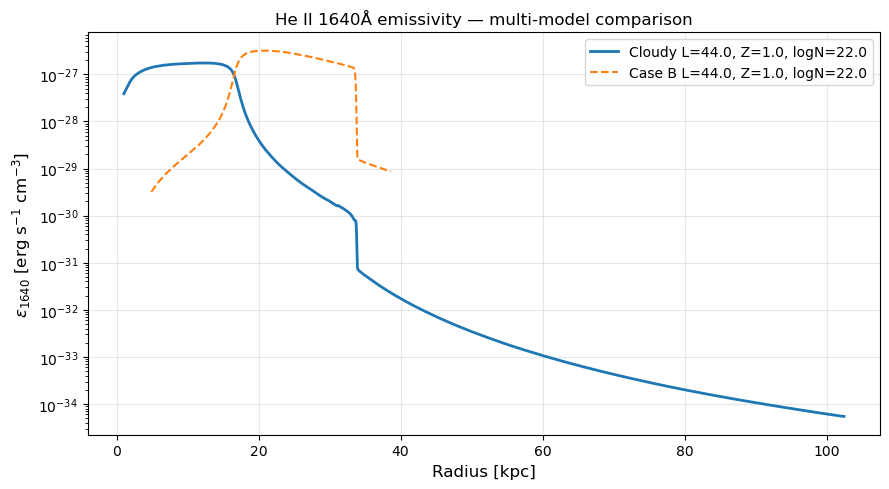

In [10]:
# 비교하고 싶은 파라미터 조합을 리스트로 추가
models = [
    (44.0, 1.0, 22.0),
    # (43.0, 1.0, 22.0),
    # (44.0, 0.1, 22.0),
]

fig, ax = plt.subplots(figsize=(9, 5))

for Lum_i, Z_i, N_i in models:
    path_i = resolve_column_density_path(Lum_i, Z_i, N_i, 'CIV/CLOUDY_QSO')
    Mod_i  = pc.CloudyModel(path_i)
    
    nH_i       = Mod_i.nH
    Te_i       = Mod_i.te
    ne_i       = Mod_i.ne
    HeII_i     = read_ele(path_i, 'He', 2) * nH_i * frac_He
    r_kpc_i    = Mod_i.radius / kpc
    r_cm_i     = Mod_i.radius
    
    emis_c_i   = Mod_i.get_emis('HE_2_164043A')
    j_i        = HE2.getEmissivity(Te_i, ne_i, wave=WAVE, product=False)
    emis_b_i   = j_i * ne_i * HeII_i
    
    label = f'L={Lum_i}, Z={Z_i}, logN={N_i}'
    ax.plot(r_kpc_i, emis_c_i, lw=2,   label=f'Cloudy {label}')
    ax.plot(r_kpc_i, emis_b_i, lw=1.5, ls='--', label=f'Case B {label}')

ax.set_yscale('log')
ax.set_xlabel('Radius [kpc]', fontsize=12)
ax.set_ylabel(r'$\varepsilon_{1640}$ [erg s$^{-1}$ cm$^{-3}$]', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_title('He II 1640Å emissivity — multi-model comparison')
plt.tight_layout()
plt.show()